# Inicios


In [1]:
import sys
from pathlib import Path
import pandas as pd
sys.path.insert(0, str(Path.cwd().parents[0] / "src"))
import numpy as np

# Conectando ao phonex


In [2]:
import os
from phoenix.otel import register
import phoenix as px
from openinference.instrumentation.langchain import LangChainInstrumentor

tracer_provider = register(
  project_name="Agente-Criador-Carteira",
  endpoint="https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces",
  auto_instrument=True,
  api_key=os.getenv("PHOENIX_API_KEY")
  
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\phoenix\otel\otel.py:434: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")
Attempting to instrument while already instrumented


OpenTelemetry Tracing Details
|  Phoenix Project: Agente-Criador-Carteira
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



# Chamando agentes

In [3]:
from portfolio_optimizer import BuildGraphAvaliacaoTics, BuildGraphCriadorCarteira, StateClassification, TratandoDadosFundamentalistas, DadosFundamentalistas, transformando_data_frame_para_markdown, StateCarteira

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
graph_tics = BuildGraphAvaliacaoTics()

In [5]:
graph_tics_build = graph_tics.compile()

In [ ]:
response_tic = await graph_tics_build.ainvoke(
    StateClassification(
        {
            "tic": "PETR4",
            "data_inicio": "2024-01-01",
            "data_fim": "2025-12-31",
        }
    )
)

INFO:portfolio_optimizer.roteador_llms.roteador_llms:Iniciando roteamento LLM
INFO:portfolio_optimizer.roteador_llms.roteador_llms:🔄 Tentando provider_name=Nvidia...


In [9]:
response_tic

{'classification': 'Good',
 'analysis': 'ABEV3 shows stable revenue growth and controlled leverage (below 2x). Despite slight P/E fluctuations and margin volatility, EBITDA remains resilient. Cash flow volatility requires monitoring.',
 'tic': 'ABEV3',
 'dados_fundamentalistas': '|    |   receita_liquida |   ebitda |   lucro_por_acao | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|-----------------:|:--------------------|:------|-------------------------:|-----------------:|--------------:|------------:|--------------------------:|------------------------:|-------------------------------------:|\n|  1 |             20280 |     6450 |             0.23 | 2024-06-30 00:00:00 | ABEV3 |                     1.55 |            0.182 |         13.22 |        2.21 |                     718.2 |               

In [13]:
from typing import List
import yfinance as yf
def transformando_data_frame_para_markdown(results):
    try:
        results_pd = pd.DataFrame.from_dict(results).T
    except Exception as e:
        results_pd = pd.DataFrame.from_dict(results, orient="index").T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown

def correlacao(tics:List[str]):
        tics_yf = [tic + ".SA" for tic in tics]

        df = yf.download(tics_yf, start="2023-01-01", end="2025-01-01", interval="1mo")["Close"]
        returns = df.pct_change()[4:]
        # Calcula a matriz de correlação
        correlacao = returns.corr()

        return correlacao.to_markdown()

In [10]:
import json
with open("avaliacao_acoes.json", "r") as f:
    response = json.load(f)

In [11]:
response_markdown = transformando_data_frame_para_markdown(response)

In [14]:
corr_tics = correlacao(list(response.keys()))

[*********************100%***********************]  10 of 10 completed


In [15]:
corr_tics

'| Ticker   |   ABEV3.SA |   BBAS3.SA |   BBDC4.SA |   GGBR4.SA |   ITUB4.SA |    LREN3.SA |   MGLU3.SA |   PETR4.SA |   RENT3.SA |    VALE3.SA |\n|:---------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|-----------:|-----------:|------------:|\n| ABEV3.SA |  1         |  0.63875   |   0.798135 |  0.294022  |  0.653014  |  0.765923   | 0.526548   |  0.26024   |   0.510053 |  0.0391883  |\n| BBAS3.SA |  0.63875   |  1         |   0.662714 | -0.0405797 |  0.769083  |  0.649864   | 0.53167    |  0.291556  |   0.559947 |  0.126629   |\n| BBDC4.SA |  0.798135  |  0.662714  |   1        |  0.18058   |  0.722328  |  0.890005   | 0.562169   |  0.335968  |   0.578476 |  0.060703   |\n| GGBR4.SA |  0.294022  | -0.0405797 |   0.18058  |  1         |  0.298853  |  0.109001   | 0.276684   |  0.130242  |   0.36652  |  0.450482   |\n| ITUB4.SA |  0.653014  |  0.769083  |   0.722328 |  0.298853  |  1         |  0.766775   | 0.705955   |  0.0120049 |   0.7

In [16]:
gaph_weights = BuildGraphCriadorCarteira()
graph_weights_build = gaph_weights.compile()

In [17]:
tics = list(response.keys())
tics

['VALE3',
 'PETR4',
 'ITUB4',
 'BBDC4',
 'ABEV3',
 'MGLU3',
 'BBAS3',
 'GGBR4',
 'RENT3',
 'LREN3']

In [ ]:
response_pesos = await graph_weights_build.ainvoke(
    StateCarteira({
    "justification" : "",
    "avaliacao_acoes": response_markdown ,
    "correlacao_acoes": corr_tics,
    "interacao" : 0,
    "tics": tics
    }))

In [19]:
response_pesos

{'tickers_weights': {'VALE3.SA': 22.22222222222222,
  'LREN3.SA': 22.22222222222222,
  'ABEV3.SA': 16.666666666666668,
  'ITUB4.SA': 16.666666666666668,
  'PETR4.SA': 5.555555555555555,
  'MGLU3.SA': 5.555555555555555,
  'RENT3.SA': 5.555555555555555,
  'GGBR4.SA': 5.555555555555555,
  'BBDC4.SA': 0.0,
  'BBAS3.SA': 0.0},
 'justification': '... [detailed analysis and risk assessment] ...',
 'analise_avaliador_weights': 'Okay, let\'s tackle this evaluation step by step. First, I need to check the constraints because that\'s the simplest part. The total weight adds up to exactly 100%? Let\'s see: VALE3 is 26.67, ITUB4 same 26.67, ABEV3 20, LREN3 20, PETR4 4, and MGLU3 2.67. Adding those: 26.67 + 26.67 is 53.34, plus 20 is 73.34, plus another 20 is 93.34, plus 4 is 97.34, then 2.67 brings it to 100 exactly. So that constraint is met.\n\nNext, check individual weights. The max allowed is 20%. VALE3 has 26.67 and ITUB4 also 26.67. Oh, that\'s way over the max 20%. So those two are violation

In [20]:
tics_selecionados = list(response_pesos['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

['VALE3.SA', 'LREN3.SA', 'ABEV3.SA', 'ITUB4.SA', 'PETR4.SA', 'MGLU3.SA', 'RENT3.SA', 'GGBR4.SA', 'BBDC4.SA', 'BBAS3.SA']


[*********************100%***********************]  10 of 10 completed


In [21]:
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize

def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

In [22]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None


In [23]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 tics_selecionados, 
                 pesos_carteira, 
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.tics_selecionados = tics_selecionados
        self.pesos_carteira = pesos_carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        
    def carregando_dados(self):
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(self.tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self):
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        
        print("📊 Métricas de Comparação das Carteiras")
        
        print("="*40)
        #display(metrics.style.format("{:.2%}").set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))

        
        # ===============================================================
        # Gráfico
        # ===============================================================
        

        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz (Valor inicial de R$ {self.valor_investido})")
        #plt.ylim(bottom=0, top=self.valor_investido * 2)
        plt.show()
        
        return retorno_acumulado_monetario

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  10 of 10 completed


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 244 registros obtidos

✓ Total de registros: 244
✓ Período: 2025-01-02 até 2025-12-18

📊 Métricas de Comparação das Carteiras


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.188261,0.265733,nan,-2.234258,-1.762599,nan,1.437211
IBOV,0.153046,0.301849,nan,-2.382162,-1.963529,nan,2.041657
Markowitz,0.143664,0.329574,nan,-2.167238,-1.866720,nan,2.319457


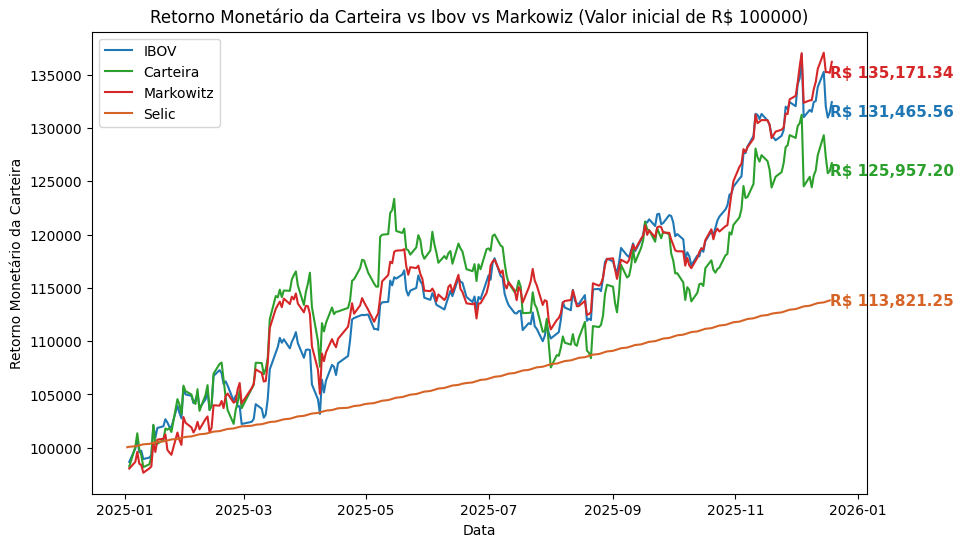

,IBOV,Carteira,Markowitz,Selic
Date,,,,
2025-01-02,NaN,NaN,NaN,100045.513000
2025-01-03,98674.713840,98228.731952,98047.228506,100091.046714
2025-01-06,99914.255983,100070.099435,98665.839698,100136.601152
2025-01-07,100864.099896,101353.927273,99616.968843,100182.176324
2025-01-08,99583.766909,99858.317623,98496.072706,100227.772238
...,...,...,...,...
2025-12-15,135260.770031,129319.172148,137054.737129,113633.205808
2025-12-16,132010.822060,127284.664242,135232.874447,113695.852931
2025-12-17,130969.406868,125751.376714,135238.425331,113758.534592


In [24]:
pesos = list(response_pesos['tickers_weights'].values()) 
comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)
comp.print_results()

In [5]:
import datetime
import pandas as pd
data_atual = datetime.datetime.now()



In [8]:
trimestres = pd.date_range(end=data_atual, periods=9, freq='QE')
trimestres[0].strftime('%Y-%m-%d')

'2023-09-30'

In [10]:
pd.date_range(end=data_atual, periods=9, freq='QE')

DatetimeIndex(['2023-09-30 09:46:46.561169', '2023-12-31 09:46:46.561169',
               '2024-03-31 09:46:46.561169', '2024-06-30 09:46:46.561169',
               '2024-09-30 09:46:46.561169', '2024-12-31 09:46:46.561169',
               '2025-03-31 09:46:46.561169', '2025-06-30 09:46:46.561169',
               '2025-09-30 09:46:46.561169'],
              dtype='datetime64[ns]', freq='QE-DEC')